In [2]:
import geokit as gk

import numpy as np
import geokit.core.extent
import geokit.core.srs
from geokit.core.get_test_data import get_test_data


In [11]:

path = "/shared_data/GEBCO_GeneralBathymetricChartOfTheOceans_GEBCO_2025/gebco_2025/gebco_2025_n90.0_s0.0_w0.0_e90.0.tif"
out_path = "/fast/home/d-marmullaku/Projects/Hackathon_3/reskit/reskit/_test/data/water_depth_northsea.tif"
shapefile = "/projects2/2023-d-marmullaku-phd/shapefiles/NUTS_RG_60M_2021_4326.shp"

ext = geokit.core.extent.Extent(
    5.0, 53.5, 8.5, 56.0,
    srs=geokit.core.srs.EPSG4326
)

ext.warp(
    source=path,
    output=out_path,
    resampleAlg="bilinear",
    pixelWidth=0.01,
    pixelHeight=0.01,
)

'/fast/home/d-marmullaku/Projects/Hackathon_3/reskit/reskit/_test/data/water_depth_northsea.tif'

/fast/home/d-marmullaku/Projects/Hackathon_3/reskit/reskit/_test/data/water_depth_northsea.tif


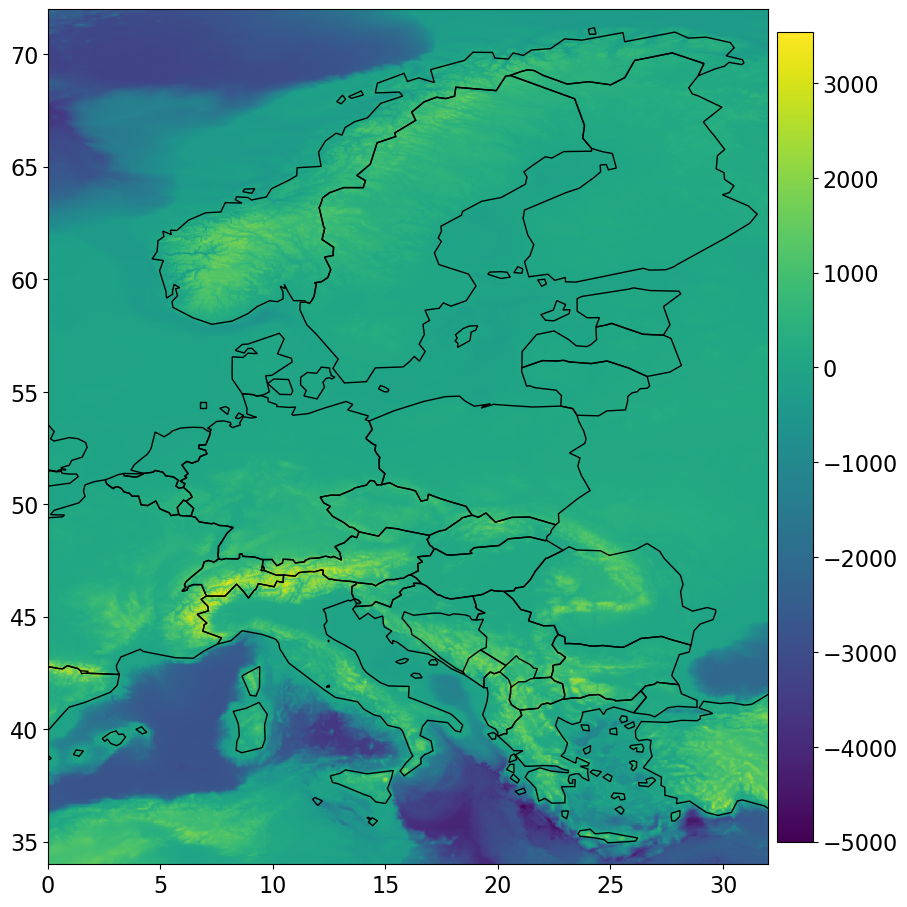

In [13]:
import geokit
import matplotlib.pyplot as plt
from geokit.core.extent import Extent
from geokit.core.srs import EPSG4326

# Europe view
europe_ext = Extent(0.0, 34.0, 32.0, 72.0, srs=EPSG4326)

europe_raster = europe_ext.warp(
    source=path,
    pixelWidth=0.05,
    pixelHeight=0.05,
    resampleAlg="bilinear",
)

lon_center = 6.9
lat_center = 54.4
dx = 0.25
dy = 0.25

northsea_ext = Extent(
    lon_center - dx / 2,
    lat_center - dy / 2,
    lon_center + dx / 2,
    lat_center + dy / 2,
    srs=EPSG4326,
)

northsea_raster = northsea_ext.warp(
    source=path,
    output=out_path,
    pixelWidth=0.01,
    pixelHeight=0.01,
    resampleAlg="bilinear",
)

print(out_path)


# plot raster
axh = geokit.core.raster.drawRaster(europe_raster, figsize=(9, 9))
ax = axh.ax if hasattr(axh, "ax") else plt.gca()

# plot boundaries
features = geokit.core.vector.extractFeatures(shapefile)

if "LEVL_CODE" in features.columns:
    feats_to_plot = features[features["LEVL_CODE"] == 0]
    if len(feats_to_plot) == 0:
        feats_to_plot = features
else:
    feats_to_plot = features

for geom in feats_to_plot["geom"]:
    geokit.core.geom.drawGeoms(
        geom,
        ax=ax,
        fc="none",
    )

geokit.core.geom.drawGeoms(
    northsea_ext.box,
    ax=ax,
    fc="none",
)

ax.set_xlim(0, 32)
ax.set_ylim(34, 72)
plt.show()

In [14]:

path = "/shared_data/NASA_DistanceToNearestCoast_v200906/GMT_intermediate_coast_distance_01d.tif"
out_path = "/fast/home/d-marmullaku/Projects/Hackathon_3/reskit/reskit/_test/data/coast_distance_northsea.tif"
shapefile = "/projects2/2023-d-marmullaku-phd/shapefiles/NUTS_RG_60M_2021_4326.shp"


ext = geokit.core.extent.Extent(
    5.0, 53.5, 8.5, 56.0,
    srs=geokit.core.srs.EPSG4326
)

ext.warp(
    source=path,
    output=out_path,
    resampleAlg="bilinear",
    pixelWidth=0.01,
    pixelHeight=0.01,
)



'/fast/home/d-marmullaku/Projects/Hackathon_3/reskit/reskit/_test/data/coast_distance_northsea.tif'

/fast/home/d-marmullaku/Projects/Hackathon_3/reskit/reskit/_test/data/coast_distance_northsea.tif


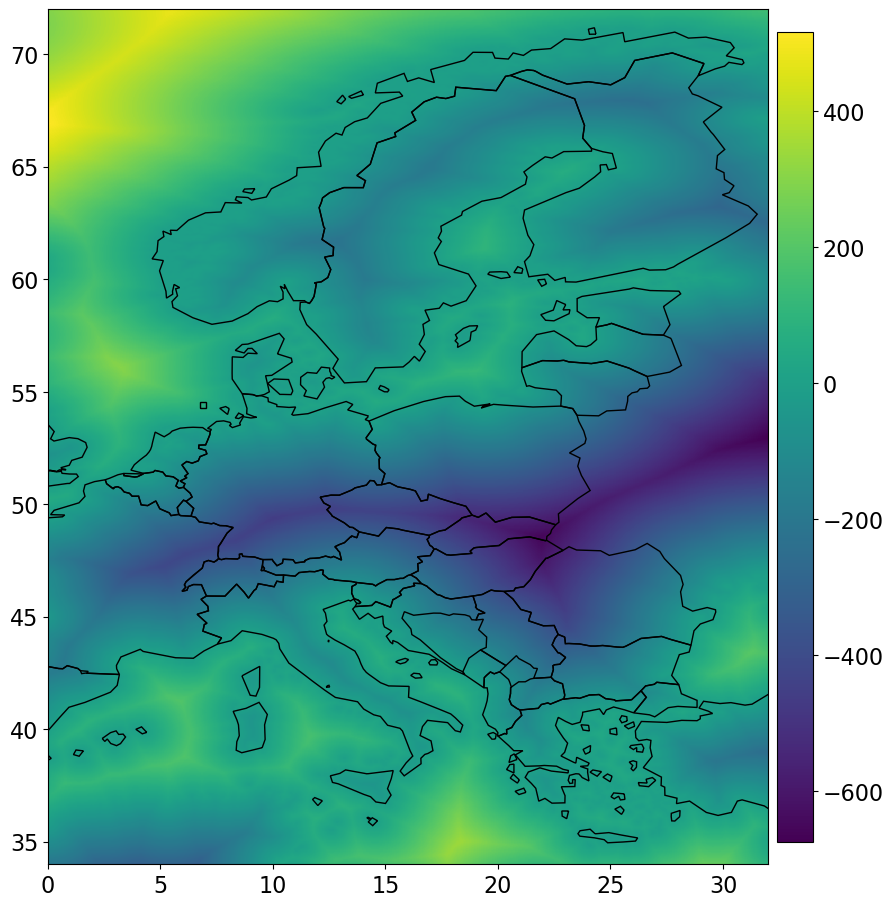

In [15]:
import geokit
import matplotlib.pyplot as plt
from geokit.core.extent import Extent
from geokit.core.srs import EPSG4326

# Europe view
europe_ext = Extent(0.0, 34.0, 32.0, 72.0, srs=EPSG4326)

europe_raster = europe_ext.warp(
    source=path,
    pixelWidth=0.05,
    pixelHeight=0.05,
    resampleAlg="bilinear",
)

lon_center = 6.9
lat_center = 54.4
dx = 0.25
dy = 0.25

northsea_ext = Extent(
    lon_center - dx / 2,
    lat_center - dy / 2,
    lon_center + dx / 2,
    lat_center + dy / 2,
    srs=EPSG4326,
)

northsea_raster = northsea_ext.warp(
    source=path,
    output=out_path,
    pixelWidth=0.01,
    pixelHeight=0.01,
    resampleAlg="bilinear",
)

print(out_path)


# plot raster
axh = geokit.core.raster.drawRaster(europe_raster, figsize=(9, 9))
ax = axh.ax if hasattr(axh, "ax") else plt.gca()

# plot boundaries
features = geokit.core.vector.extractFeatures(shapefile)

if "LEVL_CODE" in features.columns:
    feats_to_plot = features[features["LEVL_CODE"] == 0]
    if len(feats_to_plot) == 0:
        feats_to_plot = features
else:
    feats_to_plot = features

for geom in feats_to_plot["geom"]:
    geokit.core.geom.drawGeoms(
        geom,
        ax=ax,
        fc="none",
    )

geokit.core.geom.drawGeoms(
    northsea_ext.box,
    ax=ax,
    fc="none",
)

ax.set_xlim(0, 32)
ax.set_ylim(34, 72)
plt.show()